In [ ]:
import os
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import tensorflow as tf
Adam = tf.keras.optimizers.Adam
from tensorflow.keras.layers import Conv2D,MaxPool2D,Flatten,Dense,Dropout

## **Visualizing Single Audio**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
random_file_name = "/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Juju/Trimmed/Juju 020.wav"

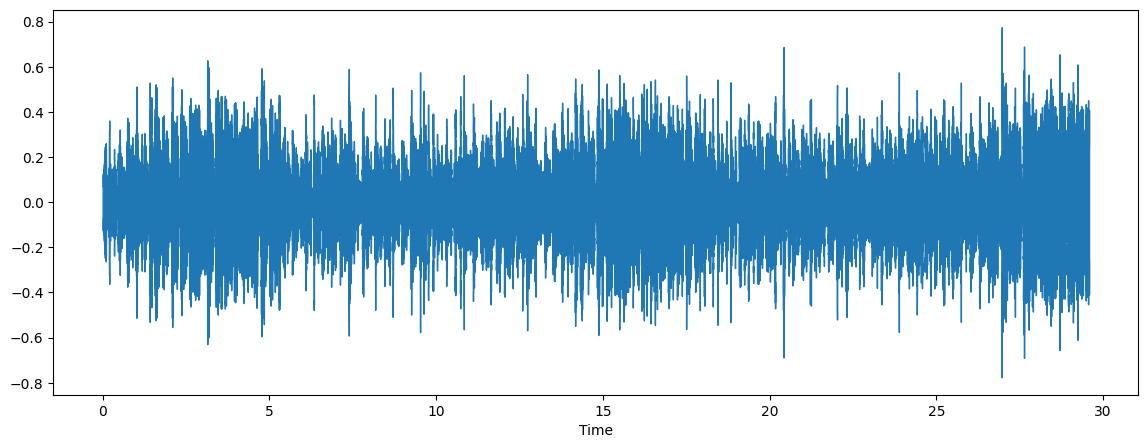

In [ ]:
y,sr = librosa.load(random_file_name,sr=44100)
plt.figure(figsize=(14,5))
librosa.display.waveshow(y,sr=sr)

In [ ]:
y.shape

(1304667,)

## **Playing Sound**

In [ ]:
from IPython.display import Audio
Audio(data=y,rate=sr)

In [ ]:
y

array([-0.05556356, -0.0540317 , -0.04786005, ..., -0.01460036,
       -0.02545037,  0.        ], dtype=float32)

## **Performing Visualization on Chunks of Audio**

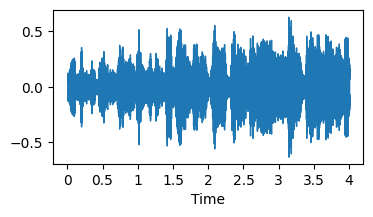

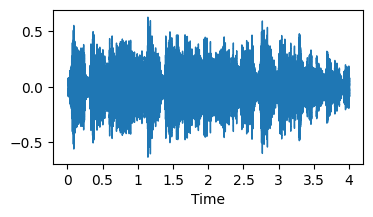

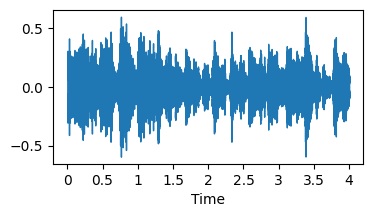

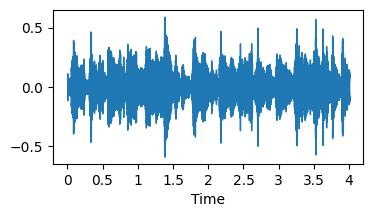

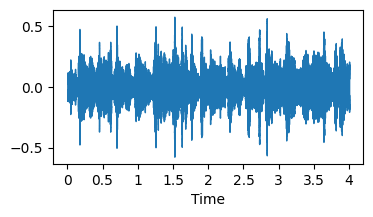

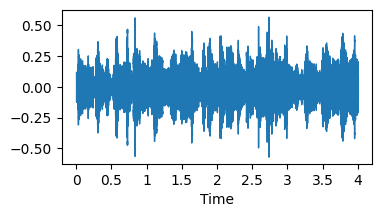

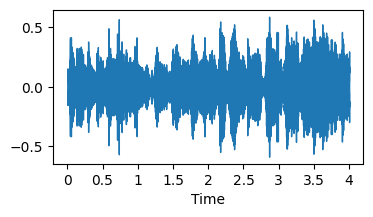

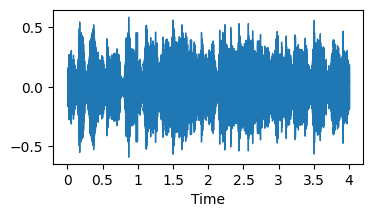

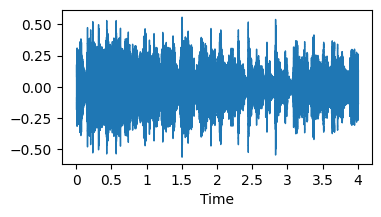

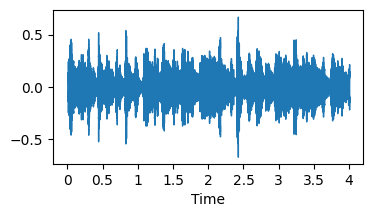

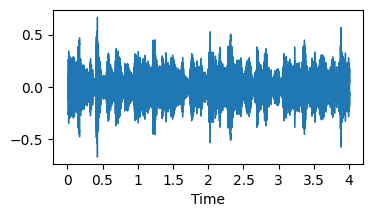

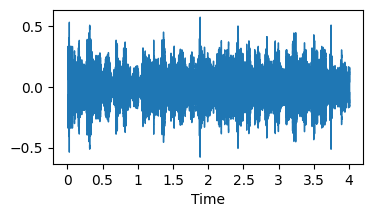

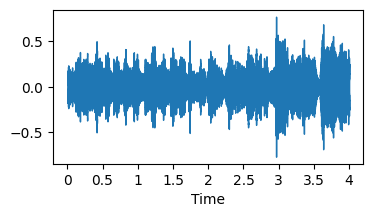

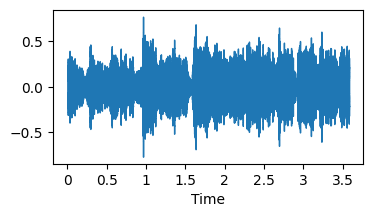

In [ ]:
audio_path = "/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Juju/Trimmed/Juju 020.wav"
y, sr = librosa.load(audio_path, sr=None)  # sr=None to keep the original sampling rate

# Define the duration of each chunk and overlap
chunk_duration = 4  # seconds
overlap_duration = 2  # seconds

# Convert durations to samples
chunk_samples = chunk_duration * sr
overlap_samples = overlap_duration * sr

# Calculate the number of chunks
num_chunks = int(np.ceil((len(y) - chunk_samples) / (chunk_samples - overlap_samples))) + 1

# Iterate over each chunk
for i in range(num_chunks):
    # Calculate start and end indices of the chunk
    start = i * (chunk_samples - overlap_samples)
    end = start + chunk_samples

    # Extract the chunk of audio
    chunk = y[start:end]
    plt.figure(figsize=(4, 2))
    librosa.display.waveshow(chunk, sr=sr)
    plt.show()

## **Melspectrogram Visualization**

In [ ]:
#Plotting Melspectrogram of Entire Audio
def plot_melespectrogram(y,sr):
    #Compute spectrogram
    spectrogram = librosa.feature.melspectrogram(y=y,sr=sr)
    #Convert to decibels (log scale)
    spectrogram_db = librosa.power_to_db(spectrogram,ref=np.max)
    #Visualize the spectrogram
    plt.figure(figsize=(10,4))
    librosa.display.specshow(spectrogram_db,sr=sr,x_axis='time',y_axis='mel')
    plt.colorbar(format='%2.0f dB')
    plt.title("Spectrogram")
    plt.tight_layout()
    plt.show()

In [ ]:
random_file_name = "/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Juju/Trimmed/Juju 020.wav"
y,sr = librosa.load(random_file_name,sr=44100)

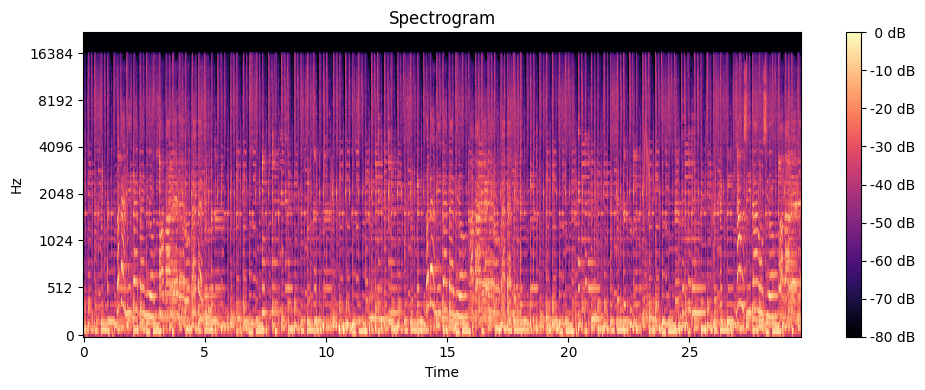

In [ ]:
plot_melespectrogram(y,sr)

In [ ]:
def plot_melspectrogram_chunks(y,sr):
    #define the duration of each chunk and overlap
    chunk_duration = 4
    overlap_duration = 2

    #Convert duration to sample
    chunk_samples = chunk_duration * sr
    overlap_samples = overlap_duration * sr

    #Calculate the number of chunks
    num_chunks = int(np.ceil((len(y)-chunk_samples)/(chunk_samples-overlap_samples)))+1

    #iterate over each chunks
    for i in range(num_chunks):
        #Calculate start and end indices of the chunk
        start = i*(chunk_samples-overlap_samples)
        end = start+chunk_samples
        #Extract the chunk audio
        chunk = y[start:end]
        #Melspectrogram part
        spectrogram = librosa.feature.melspectrogram(y=chunk,sr=sr)
        print(spectrogram.shape)
        spectrogram_db = librosa.power_to_db(spectrogram,ref=np.max)
        #Visualize the spectrogram
        plt.figure(figsize=(10,4))
        librosa.display.specshow(spectrogram_db,sr=sr,x_axis='time',y_axis='mel')
        plt.colorbar(format='%2.0f dB')
        plt.title("Spectrogram")
        plt.tight_layout()
        plt.show()

In [ ]:
random_file_name = "/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Juju/Trimmed/Juju 020.wav"
y,sr = librosa.load(random_file_name,sr=44100)

(128, 345)


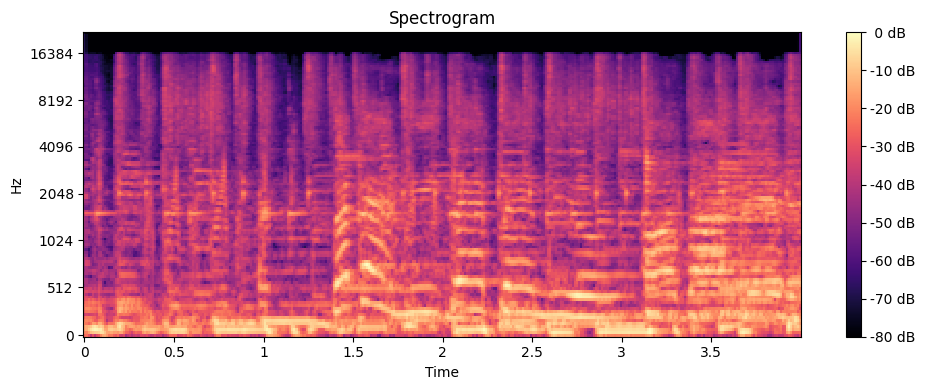

(128, 345)


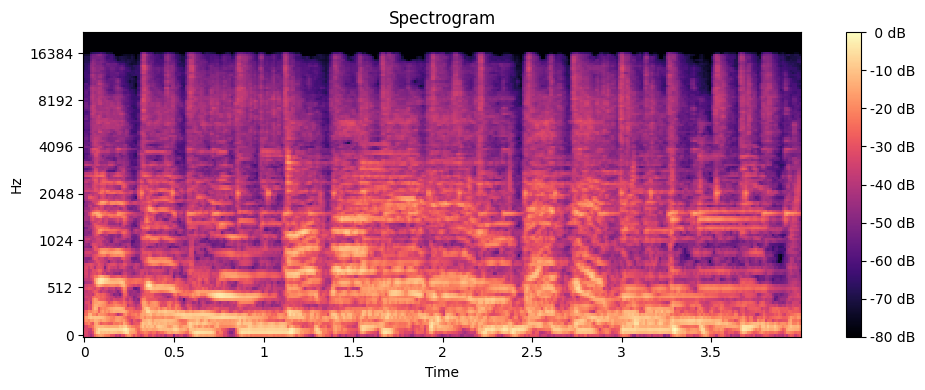

(128, 345)


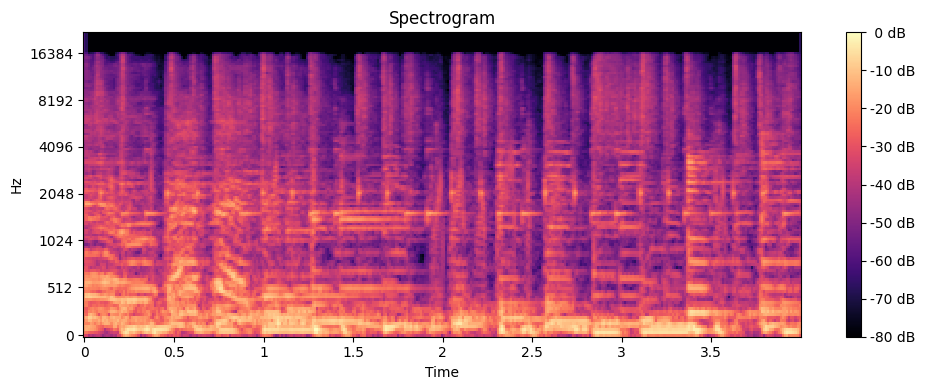

(128, 345)


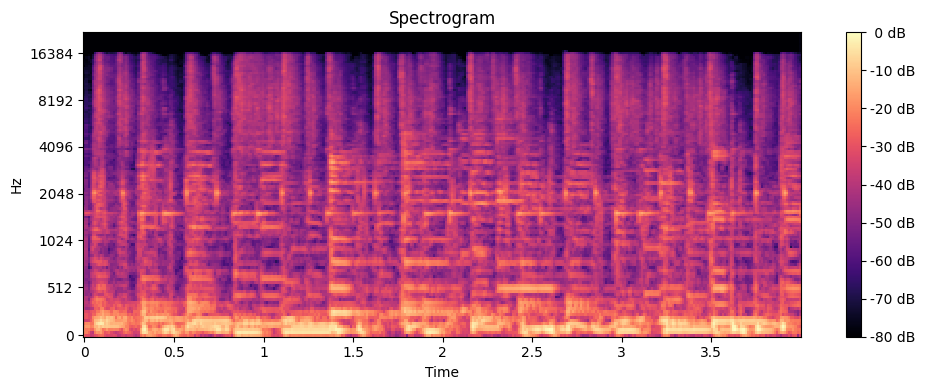

(128, 345)


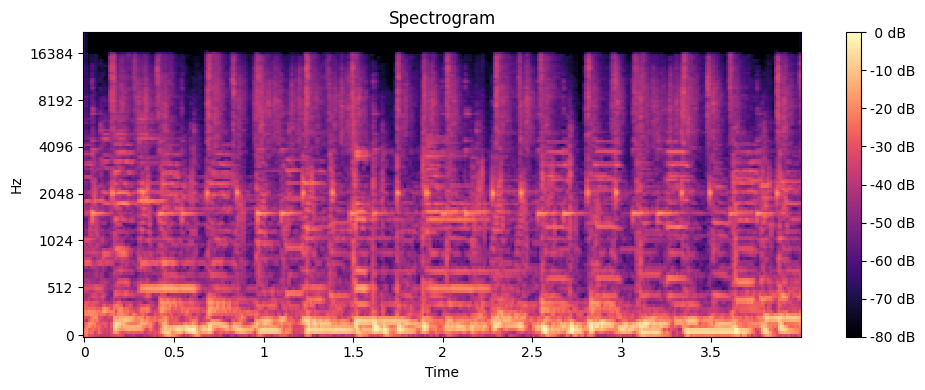

(128, 345)


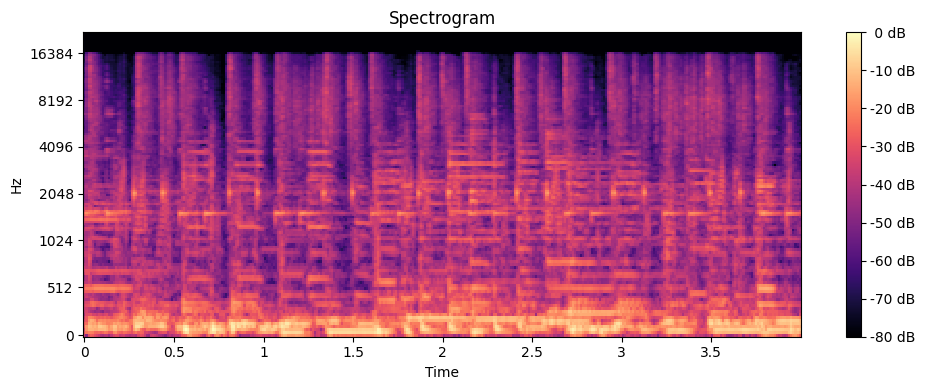

(128, 345)


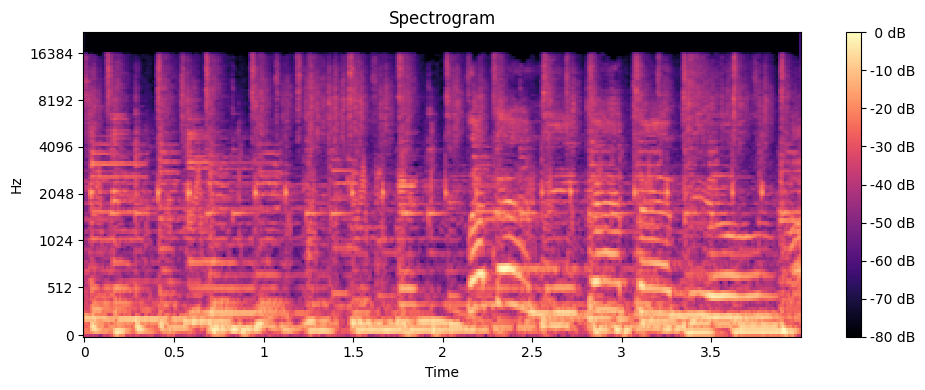

(128, 345)


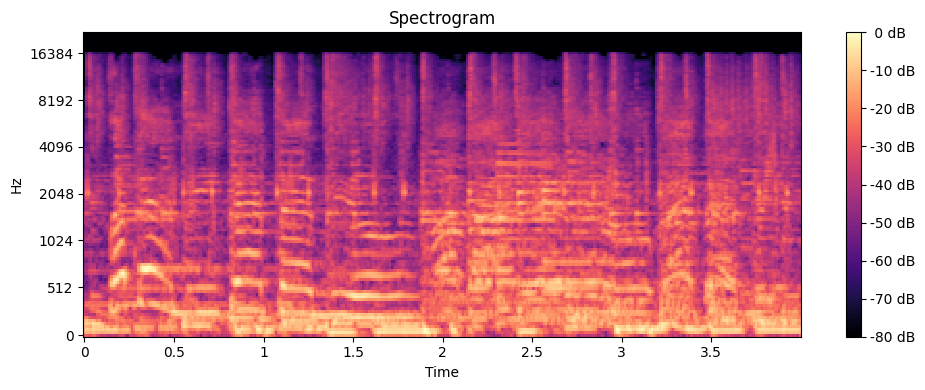

(128, 345)


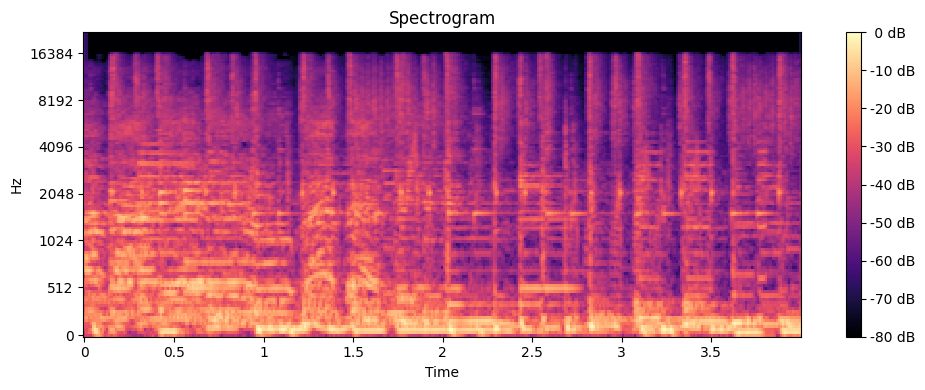

(128, 345)


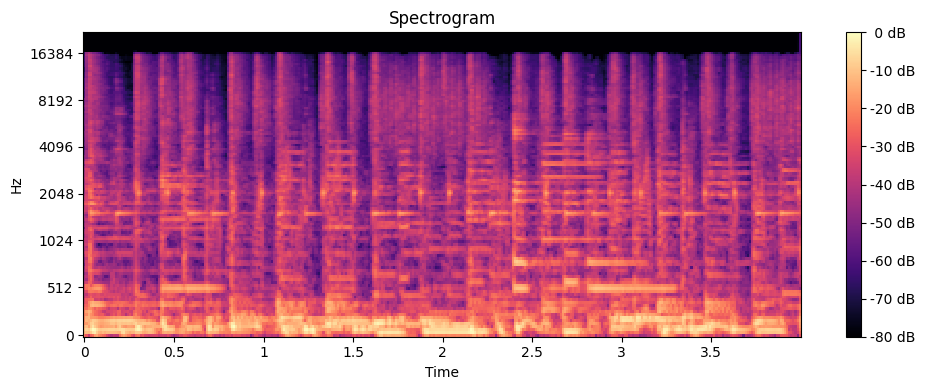

(128, 345)


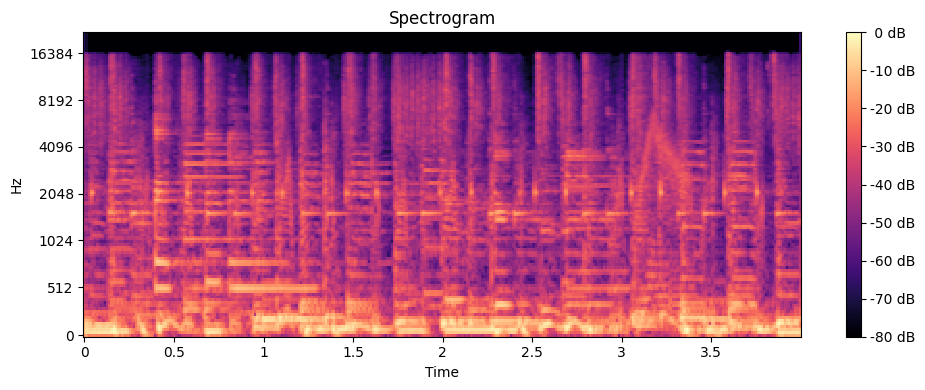

(128, 345)


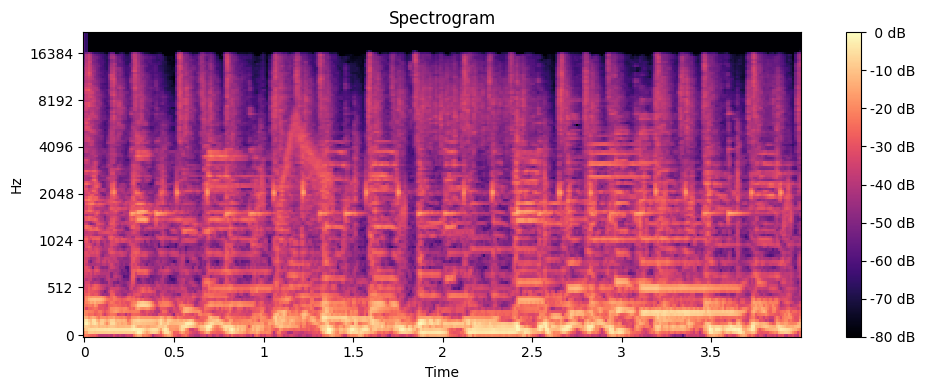

(128, 345)


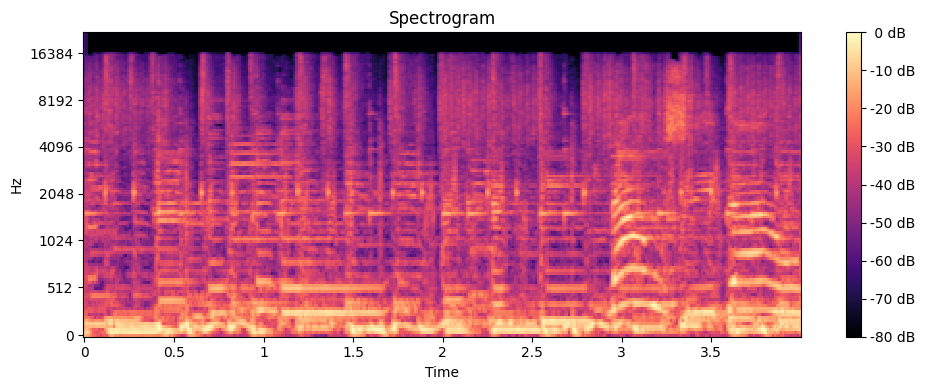

(128, 309)


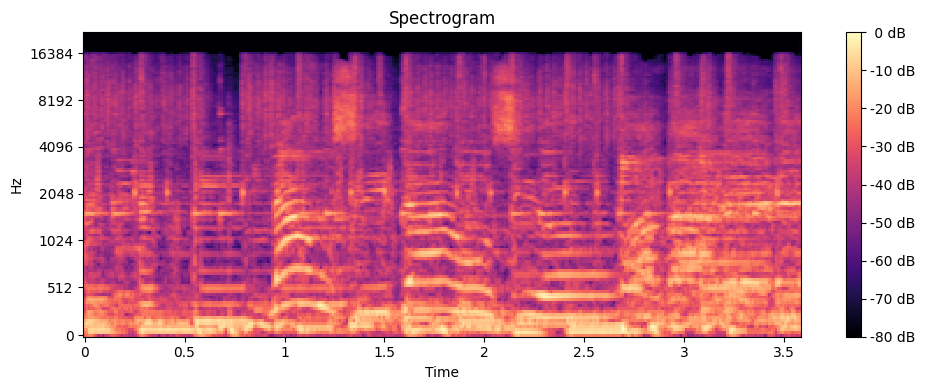

In [ ]:
plot_melspectrogram_chunks(y,sr)

In [ ]:
128*345

44160

In [ ]:
210*210

44100

In [ ]:
#define your folder structure
data_dir = "/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset"
classes = ['/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Afrobeat/Trimmed',
           '/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Afrobeats/Trimmed',
           '/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Amapiano/Trimmed',
           '/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Congolese Rumba/Trimmed',
           '/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Fuji/Trimmed',
           '/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Highlife/Trimmed',
           '/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Juju/Trimmed',
           '/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Kwaito/Trimmed',
           '/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Mbalax/Trimmed',
           '/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Soukous/Trimmed']

In [ ]:
from tensorflow.image import resize
#Load and preprocess audio data
def load_and_preprocess_data(data_dir,classes,target_shape=(150,150)):
    data=[]
    labels=[]

    for i_class,class_name in enumerate(classes):
        class_dir = os.path.join(data_dir,class_name)
        print("Processing--",class_name)
        for filename in os.listdir(class_dir):
            if filename.endswith('.wav'):
                file_path = os.path.join(class_dir,filename)
                audio_data,sample_rate = librosa.load(file_path,sr=None)
                #Performing Preprocessing
                #define the duration of each chunk and overlap
                chunk_duration = 4
                overlap_duration = 2

                #Convert duration to sample
                chunk_samples = chunk_duration * sample_rate
                overlap_samples = overlap_duration * sample_rate

                #Calculate the number of chunks
                num_chunks = int(np.ceil((len(audio_data)-chunk_samples)/(chunk_samples-overlap_samples)))+1

                #iterate over each chunks
                for i in range(num_chunks):
                    #Calculate start and end indices of the chunk
                    start = i*(chunk_samples-overlap_samples)
                    end = start+chunk_samples
                    #Extract the chunk audio
                    chunk = audio_data[start:end]
                    #Melspectrogram part
                    mel_spectrogram = librosa.feature.melspectrogram(y=chunk,sr=sample_rate)
                    #Resize matrix based on provided target shape
                    mel_spectrogram = resize(np.expand_dims(mel_spectrogram,axis=-1),target_shape)
                    #Append data to list
                    data.append(mel_spectrogram)
                    labels.append(i_class)
    #Return
    return np.array(data),np.array(labels)

In [ ]:
data,labels = load_and_preprocess_data(data_dir,classes)

Processing-- /content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Afrobeat/Trimmed
Processing-- /content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Afrobeats/Trimmed
Processing-- /content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Amapiano/Trimmed
Processing-- /content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Congolese Rumba/Trimmed
Processing-- /content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Fuji/Trimmed
Processing-- /content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Highlife/Trimmed
Processing-- /content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Juju/Trimmed
Processing-- /content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Kwaito/Trimmed
Processing-- /content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Mbalax/Trimmed
Processing-- /content/drive/MyDrive/African Music Genre cla

In [ ]:
data.shape

(15163, 150, 150, 1)

In [ ]:
labels.shape

(15163,)

In [ ]:
from tensorflow.keras.utils import to_categorical
labels = to_categorical(labels,num_classes = len(classes)) # Converting labels to one-hot encoding
labels

array([[[0., 1., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]],

       [[0., 1., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]],

       [[0., 1., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0.

In [ ]:
labels.shape

(15163, 10, 10)

## **Splitting African Music Genres Dataset Into Train and Test Dataset**

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(data,labels,test_size=0.2,random_state=42)

In [ ]:
model = tf.keras.models.Sequential()

In [ ]:
X_train[0].shape

(150, 150, 1)

In [ ]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=X_train[0].shape))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [ ]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [ ]:
model.add(Dropout(0.3))

In [ ]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [ ]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [ ]:
model.add(Dropout(0.3))

In [ ]:
model.add(Flatten())

In [ ]:
model.add(Dense(units=1200,activation='relu'))

In [ ]:
model.add(Dropout(0.45))

In [ ]:
#Output layer
model.add(Dense(units=len(classes),activation='softmax'))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 148, 148, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 74, 74, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 17, 17, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 5, 5, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1200)           │     2,458,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,182,458 (27.40 MB)

 Trainable params: 7,182,458 (27.40 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
import keras, tensorflow as tf
print("keras version:", keras.__version__)
print("tf version:", tf.__version__)

keras version: 3.10.0
tf version: 2.19.0


In [ ]:
#Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

## **Model Training**

In [ ]:
#Training Model
training_history = model.fit(X_train,Y_train,epochs=30,batch_size=32,validation_data=(X_test,Y_test))

Epoch 1/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 47s 105ms/step - accuracy: 0.4382 - loss: 1.5774 - val_accuracy: 0.5414 - val_loss: 1.3354
Epoch 2/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 33s 87ms/step - accuracy: 0.5490 - loss: 1.2872 - val_accuracy: 0.6040 - val_loss: 1.1375
Epoch 3/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 33s 86ms/step - accuracy: 0.6364 - loss: 1.0473 - val_accuracy: 0.6756 - val_loss: 0.8967
Epoch 4/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 33s 86ms/step - accuracy: 0.6905 - loss: 0.8841 - val_accuracy: 0.7310 - val_loss: 0.7758
Epoch 5/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 33s 86ms/step - accuracy: 0.7585 - loss: 0.6846 - val_accuracy: 0.7567 - val_loss: 0.6952
Epoch 6/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 33s 86ms/step - accuracy: 0.8087 - loss: 0.5433 - val_accuracy: 0.8068 - val_loss: 0.5849
Epoch 7/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 33s 86ms/step - accuracy: 0.8385 - loss: 0.4572 - val_accuracy: 0.8111 - val_loss: 0.5710
Epoch 8/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 33s 86ms/step - accuracy: 0.8712 - loss: 0.3717 -

In [ ]:
import os

save_dir = "/content/drive/MyDrive/African Music Genre classifier Dataset"
os.makedirs(save_dir, exist_ok=True)

model.save(os.path.join(save_dir, "Trained_model.keras"))
model.save(os.path.join(save_dir, "Trained_model.h5"))

In [ ]:
import os

save_dir = "/content/drive/MyDrive/African Music Genre classifier Dataset"
os.makedirs(save_dir, exist_ok=True)

model.save(os.path.join(save_dir, "Trained_model.keras"))

In [ ]:
model.export(os.path.join(save_dir, "Trained_model_savedmodel"))

Saved artifact at '/content/drive/MyDrive/African Music Genre classifier Dataset/Trained_model_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  135404549914896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135404549917392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135404549915664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135404549915088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135404549919312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135404549920080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135404549919504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135404549917584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135404549920656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1354045499208

In [ ]:
model.save(os.path.join(save_dir, "Trained_model.h5"))

In [ ]:
training_history.history

{'accuracy': [0.46768343448638916,
  0.5694146752357483,
  0.6553173661231995,
  0.7121186852455139,
  0.7678483128547668,
  0.8100576996803284,
  0.8450947999954224,
  0.8700742125511169,
  0.8895300626754761,
  0.9147567749023438,
  0.924319863319397,
  0.9451772570610046,
  0.9484748840332031,
  0.9530090689659119,
  0.9669414758682251,
  0.9533388018608093,
  0.9690024852752686,
  0.9730420708656311,
  0.974196195602417,
  0.9751855134963989,
  0.980791449546814,
  0.9807089567184448,
  0.975432813167572,
  0.9840890169143677,
  0.9781533479690552,
  0.9840890169143677,
  0.978565514087677,
  0.9894476532936096,
  0.9879637360572815,
  0.966694176197052],
 'loss': [1.518114447593689,
  1.2402912378311157,
  0.9951077103614807,
  0.8238844275474548,
  0.6530592441558838,
  0.5394138693809509,
  0.4419437348842621,
  0.3767116367816925,
  0.3196563720703125,
  0.2411116361618042,
  0.21855835616588593,
  0.15983246266841888,
  0.1536572426557541,
  0.13754843175411224,
  0.1050557866

In [ ]:
#Recording History in json
import json
with open('training_hist.json','w') as f:
  json.dump(training_history.history,f)

In [ ]:
X_train

array([[[[5.2566701e-01],
         [1.1931091e-01],
         [1.6068758e-01],
         ...,
         [3.0961609e+00],
         [4.6422077e+01],
         [1.5395469e+01]],

        [[2.6468716e+00],
         [2.3061132e+00],
         [1.9806997e+01],
         ...,
         [1.7228058e+02],
         [8.7315033e+01],
         [2.3464254e+01]],

        [[4.0026526e+00],
         [3.1545122e+00],
         [1.6320090e+02],
         ...,
         [4.9771237e+02],
         [4.5684772e+02],
         [4.4812290e+01]],

        ...,

        [[1.5836701e-04],
         [3.0946069e-07],
         [7.4876739e-06],
         ...,
         [6.1985938e-06],
         [2.1458596e-05],
         [1.2726581e-03]],

        [[1.5472082e-04],
         [2.5162998e-07],
         [7.3017441e-06],
         ...,
         [7.9548836e-06],
         [1.9327379e-05],
         [1.2596532e-03]],

        [[1.5256017e-04],
         [2.8120985e-07],
         [7.1229838e-06],
         ...,
         [9.0880631e-06],
        

In [ ]:
#Reloading model variable
model = tf.keras.models.load_model("/content/drive/MyDrive/African Music Genre classifier Dataset/Trained_model.h5")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 148, 148, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 74, 74, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 17, 17, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 5, 5, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1200)           │     2,458,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,182,460 (27.40 MB)

 Trainable params: 7,182,458 (27.40 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
#Reloading Training history
import json
with open("training_hist.json",'r') as json_file:
    training_history_data = json.load(json_file)

In [ ]:
training_history_data.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## **Model Evaluation**

In [ ]:
#Model evaluation on Training set
train_loss,train_accuracy = model.evaluate(X_train,Y_train)

380/380 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.9897 - loss: 0.0308


In [ ]:
train_loss,train_accuracy

(0.029476584866642952, 0.9904369115829468)

In [ ]:
#Model evaluation on Validation set
val_loss,val_accuracy = model.evaluate(X_test,Y_test)

95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9083 - loss: 0.3553


In [ ]:
val_loss,val_accuracy

(0.3559150993824005, 0.9096603989601135)

In [ ]:
training_history_data['val_loss']

[1.3354036808013916,
 1.137494444847107,
 0.8966664671897888,
 0.7757555842399597,
 0.695180356502533,
 0.58488929271698,
 0.5710107684135437,
 0.5105319023132324,
 0.4125751554965973,
 0.44572219252586365,
 0.39558473229408264,
 0.4047063887119293,
 0.466584175825119,
 0.3902527391910553,
 0.45726194977760315,
 0.4561358392238617,
 0.3345765471458435,
 0.3707596957683563,
 0.35781633853912354,
 0.4190705716609955,
 0.31429463624954224,
 0.34594935178756714,
 0.3008787930011749,
 0.4079161584377289,
 0.40945276618003845,
 0.34172725677490234,
 0.3063170909881592,
 0.3011520802974701,
 0.4369056522846222,
 0.3559150993824005]

## **Accuracy and Loss Visualization**

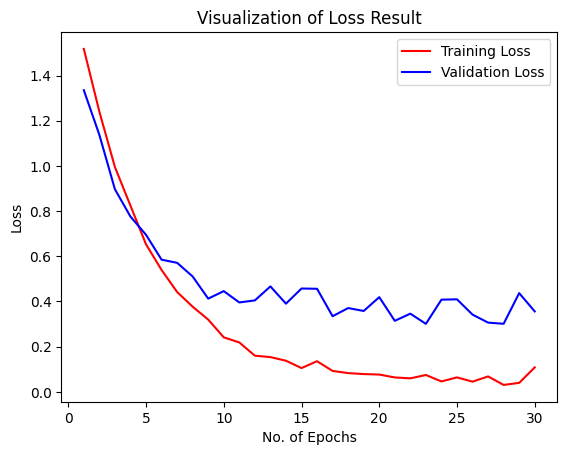

In [ ]:
#Visualization of Loss
epochs = [i for i in range(1,31)]
plt.plot(epochs,training_history_data['loss'],label="Training Loss",color='red')
plt.plot(epochs,training_history_data['val_loss'],label="Validation Loss",color='blue')
plt.xlabel("No. of Epochs")
plt.ylabel("Loss")
plt.title("Visualization of Loss Result")
plt.legend()
plt.show()

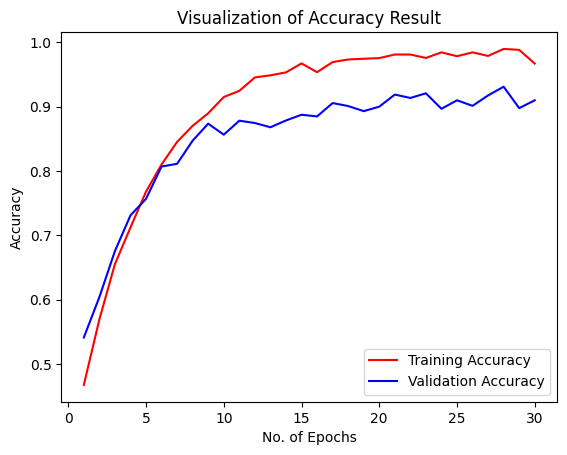

In [ ]:
#Visualization of Accuracy
epochs = [i for i in range(1,31)]
plt.plot(epochs,training_history_data['accuracy'],label="Training Accuracy",color='red')
plt.plot(epochs,training_history_data['val_accuracy'],label="Validation Accuracy",color='blue')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

## **Precision Recall Confusion Matrix**

**Model Evaluation**

In [ ]:
X_test.shape

(3033, 150, 150, 1)

In [ ]:
y_pred = model.predict(X_test)
y_pred

95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step


array([[9.6353002e-39, 6.4088268e-25, 1.0000000e+00, ..., 3.1382755e-29,
        5.1785966e-40, 2.8904443e-40],
       [2.1661972e-10, 1.9098048e-09, 2.9138140e-14, ..., 2.2409286e-09,
        1.4777000e-10, 1.8559504e-08],
       [8.0432671e-01, 1.3458231e-07, 1.5176051e-05, ..., 4.7522277e-04,
        1.7165898e-05, 1.5865469e-08],
       ...,
       [9.5094466e-01, 1.0462849e-07, 5.1554441e-09, ..., 1.9211191e-07,
        1.0967754e-05, 2.6873098e-10],
       [2.1166066e-08, 5.0213798e-06, 6.3693034e-10, ..., 7.5220200e-08,
        8.7936178e-07, 1.0223844e-01],
       [1.1855791e-07, 7.5058068e-07, 1.1658067e-09, ..., 2.2037275e-05,
        1.7005920e-03, 1.1002969e-06]], dtype=float32)

In [ ]:
y_pred.shape

(3033, 10)

In [ ]:
predicted_categories = np.argmax(y_pred,axis=1)
predicted_categories

array([2, 4, 0, ..., 0, 3, 4])

In [ ]:
Y_test

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
Y_test.shape

(3033, 10)

In [ ]:
true_categories = np.argmax(Y_test,axis=1)
true_categories

array([2, 4, 0, ..., 0, 3, 4])

In [ ]:
classes

['/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Afrobeat/Trimmed',
 '/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Afrobeats/Trimmed',
 '/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Amapiano/Trimmed',
 '/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Congolese Rumba/Trimmed',
 '/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Fuji/Trimmed',
 '/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Highlife/Trimmed',
 '/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Juju/Trimmed',
 '/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Kwaito/Trimmed',
 '/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Mbalax/Trimmed',
 '/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Soukous/Trimmed']

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(true_categories,predicted_categories)
# Precision Recall F1score
print(classification_report(true_categories,predicted_categories,target_names=classes))

                                                                                                    precision    recall  f1-score   support

       /content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Afrobeat/Trimmed       0.96      0.89      0.92       330
      /content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Afrobeats/Trimmed       0.92      0.88      0.90       317
       /content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Amapiano/Trimmed       0.98      0.94      0.96       324
/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Congolese Rumba/Trimmed       0.89      0.86      0.88       311
           /content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Fuji/Trimmed       0.89      0.96      0.92       284
       /content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Highlife/Trimmed       0.94      0.82      0.88       301
           /content

In [ ]:
cm

array([[294,   1,   1,   1,   5,   2,   8,   5,   9,   4],
       [  0, 279,   2,   7,   2,   0,   1,   1,  10,  15],
       [  0,   6, 306,   2,   1,   1,   3,   2,   0,   3],
       [  2,   6,   0, 269,   2,   5,   0,   1,   3,  23],
       [  0,   1,   0,   2, 273,   1,   6,   0,   1,   0],
       [  3,   2,   0,  13,   5, 248,   5,   1,   4,  20],
       [  1,   1,   0,   2,  11,   4, 279,   2,   4,   3],
       [  2,   2,   3,   1,   0,   0,   0, 258,   0,   6],
       [  1,   0,   1,   1,   6,   1,   3,   1, 263,   1],
       [  3,   4,   0,   4,   3,   1,   0,   1,   3, 290]])

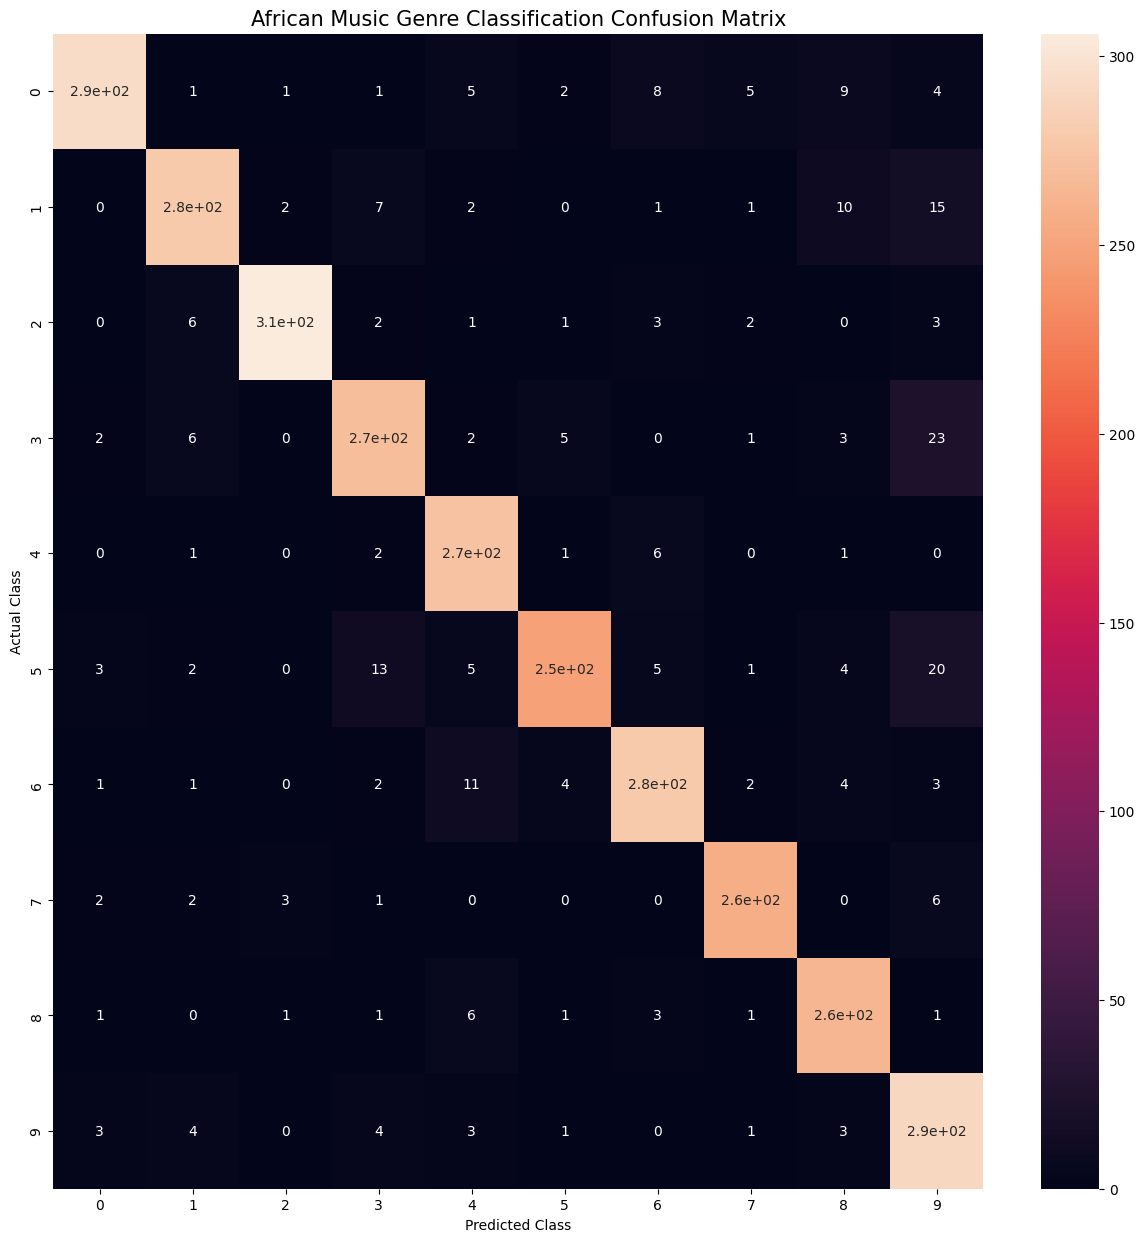

In [ ]:
import seaborn as sns
plt.figure(figsize=(15,15))
sns.heatmap(cm,annot=True,annot_kws={"size":10})
plt.xlabel("Predicted Class",fontsize=10)
plt.ylabel("Actual Class",fontsize=10)
plt.title("African Music Genre Classification Confusion Matrix",fontsize=15)
plt.show()